# Logistic Regression — Titanic Survival Prediction
**Objective:** Build and evaluate a Logistic Regression model to predict passenger survival on the Titanic using training data, and generate predictions on the test set.

---
## 0. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
import pickle

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded.')

All libraries loaded.


---
## Task 1 — Data Exploration (EDA)

In [2]:
# Load datasets
train = pd.read_csv('Titanic_train.csv')
test  = pd.read_csv('Titanic_test.csv')

print('Train shape:', train.shape)
print('Test  shape:', test.shape)
train.head()

Train shape: (891, 12)
Test  shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Feature types and summary
print('Column Data Types:')
print(train.dtypes)
print()
train.describe(include='all')

Column Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [4]:
# Missing values
def missing_report(df, name):
    m = df.isnull().sum()
    pct = (m / len(df) * 100).round(2)
    r = pd.DataFrame({'Missing': m, 'Percent (%)': pct})
    r = r[r['Missing'] > 0]
    print(f'{name} — Missing Values:')
    print(r.to_string() if len(r) else '  None')
    print()

missing_report(train, 'Titanic_train')
missing_report(test,  'Titanic_test')

Titanic_train — Missing Values:
          Missing  Percent (%)
Age           177        19.87
Cabin         687        77.10
Embarked        2         0.22

Titanic_test — Missing Values:
       Missing  Percent (%)
Age         86        20.57
Fare         1         0.24
Cabin      327        78.23



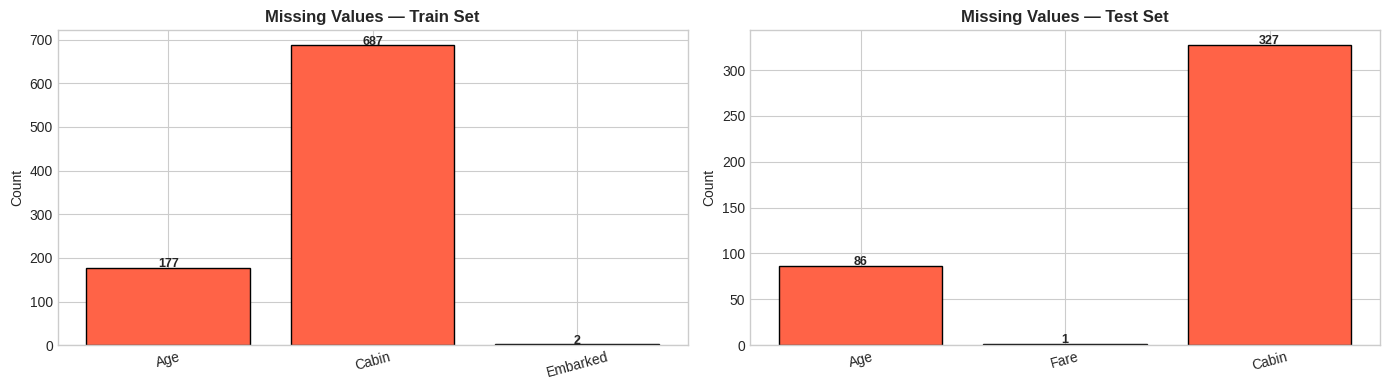

In [5]:
# Missing value heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, df, title in zip(axes, [train, test], ['Train', 'Test']):
    miss = df.isnull().sum()
    miss = miss[miss > 0]
    ax.bar(miss.index, miss.values, color='tomato', edgecolor='black')
    for i, v in enumerate(miss.values):
        ax.text(i, v + 1, str(v), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(f'Missing Values — {title} Set', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

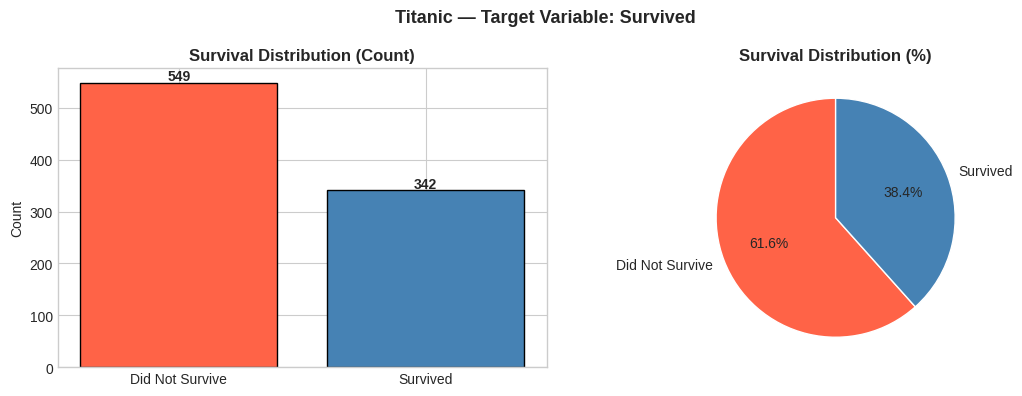

In [6]:
# --- Target distribution ---
surv_counts = train['Survived'].value_counts()
surv_labels = ['Did Not Survive', 'Survived']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
bars = axes[0].bar(surv_labels, surv_counts.sort_index().values,
                   color=['tomato', 'steelblue'], edgecolor='black')
for bar, v in zip(bars, surv_counts.sort_index().values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                 str(v), ha='center', fontweight='bold')
axes[0].set_title('Survival Distribution (Count)', fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(surv_counts.sort_index().values, labels=surv_labels,
            colors=['tomato', 'steelblue'], autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Survival Distribution (%)', fontweight='bold')

plt.suptitle('Titanic — Target Variable: Survived', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

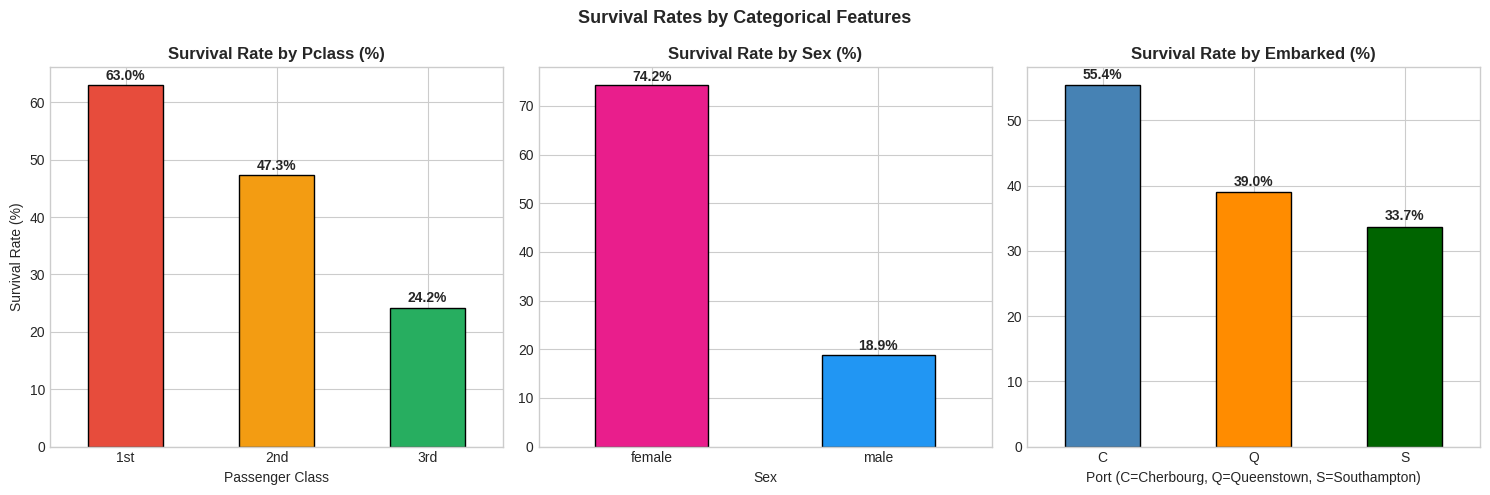

In [7]:
# --- Survival by categorical features ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# By Pclass
pclass_surv = train.groupby('Pclass')['Survived'].mean() * 100
pclass_surv.plot(kind='bar', ax=axes[0], color=['#e74c3c','#f39c12','#27ae60'],
                 edgecolor='black')
axes[0].set_title('Survival Rate by Pclass (%)', fontweight='bold')
axes[0].set_xlabel('Passenger Class')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_xticklabels(['1st', '2nd', '3rd'], rotation=0)
for i, v in enumerate(pclass_surv):
    axes[0].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# By Sex
sex_surv = train.groupby('Sex')['Survived'].mean() * 100
sex_surv.plot(kind='bar', ax=axes[1], color=['#e91e8c','#2196f3'], edgecolor='black')
axes[1].set_title('Survival Rate by Sex (%)', fontweight='bold')
axes[1].set_xlabel('Sex')
axes[1].set_xticklabels(sex_surv.index, rotation=0)
for i, v in enumerate(sex_surv):
    axes[1].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

# By Embarked
emb_surv = train.groupby('Embarked')['Survived'].mean() * 100
emb_surv.plot(kind='bar', ax=axes[2], color=['steelblue','darkorange','darkgreen'],
              edgecolor='black')
axes[2].set_title('Survival Rate by Embarked (%)', fontweight='bold')
axes[2].set_xlabel('Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
axes[2].set_xticklabels(emb_surv.index, rotation=0)
for i, v in enumerate(emb_surv):
    axes[2].text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Survival Rates by Categorical Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

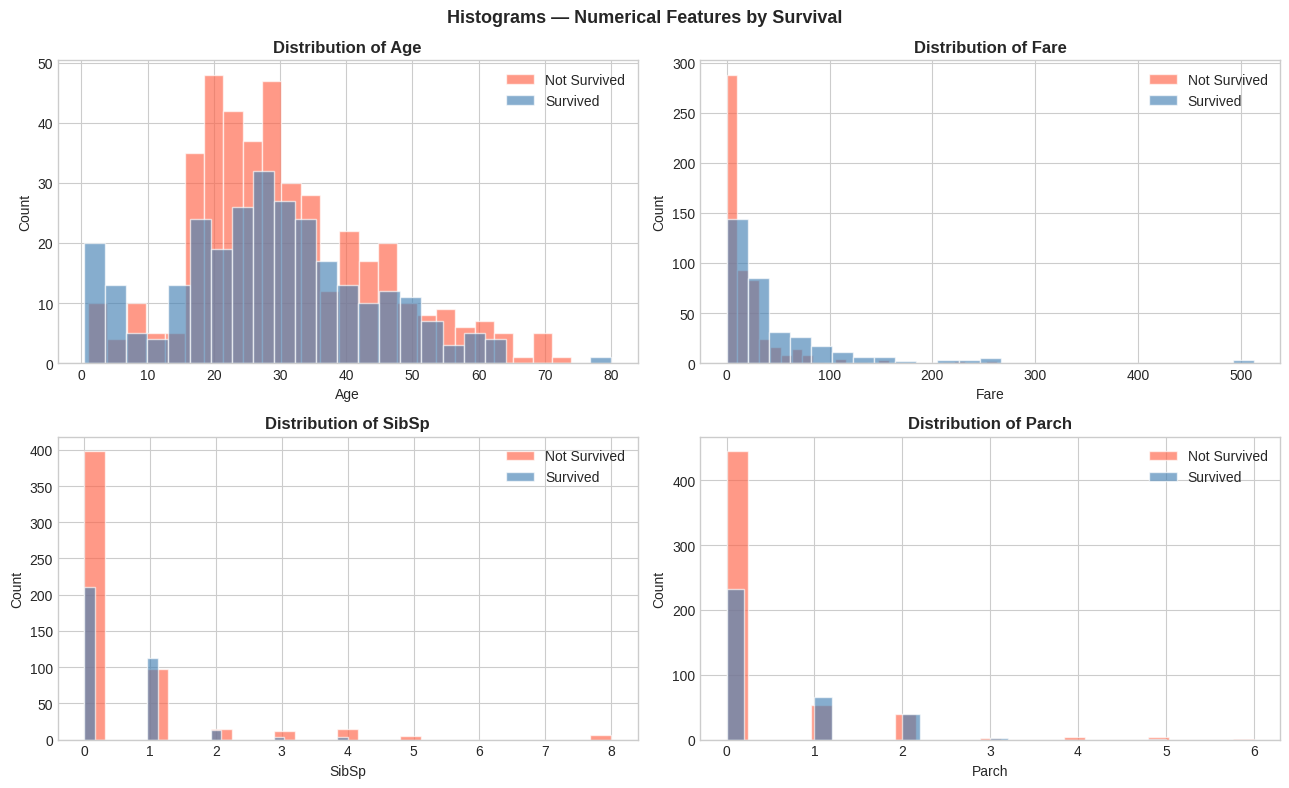

In [8]:
# --- Histograms for numerical features ---
num_feats = ['Age', 'Fare', 'SibSp', 'Parch']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()
colors_surv = {0: 'tomato', 1: 'steelblue'}

for i, col in enumerate(num_feats):
    for surv_val, color in colors_surv.items():
        subset = train[train['Survived'] == surv_val][col].dropna()
        axes[i].hist(subset, bins=25, alpha=0.65, color=color, edgecolor='white',
                     label='Survived' if surv_val == 1 else 'Not Survived')
    axes[i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Histograms — Numerical Features by Survival', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

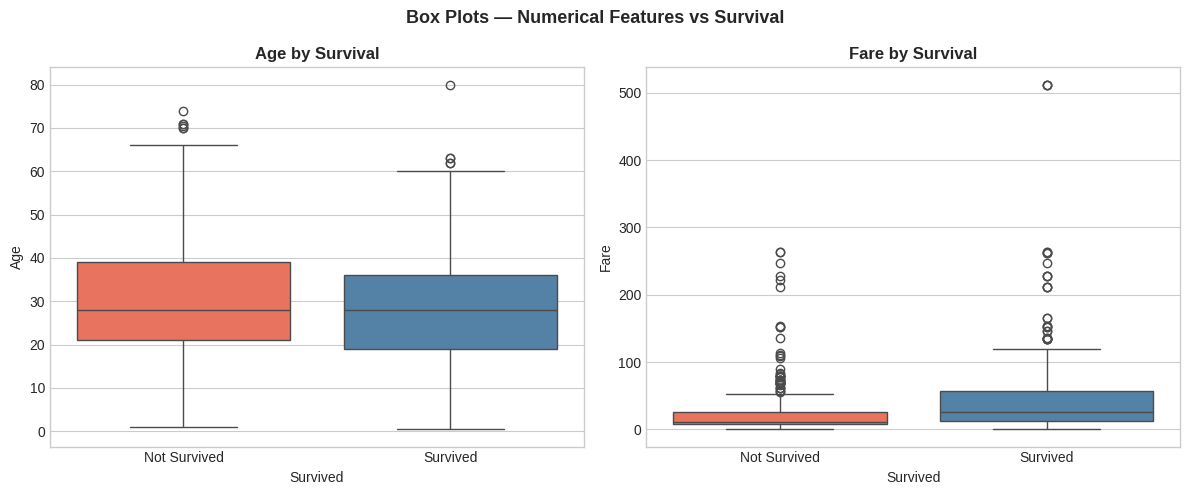

In [9]:
# --- Box plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=train, x='Survived', y='Age', ax=axes[0],
            palette=['tomato', 'steelblue'])
axes[0].set_title('Age by Survival', fontweight='bold')
axes[0].set_xticklabels(['Not Survived', 'Survived'])

sns.boxplot(data=train, x='Survived', y='Fare', ax=axes[1],
            palette=['tomato', 'steelblue'])
axes[1].set_title('Fare by Survival', fontweight='bold')
axes[1].set_xticklabels(['Not Survived', 'Survived'])

plt.suptitle('Box Plots — Numerical Features vs Survival', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

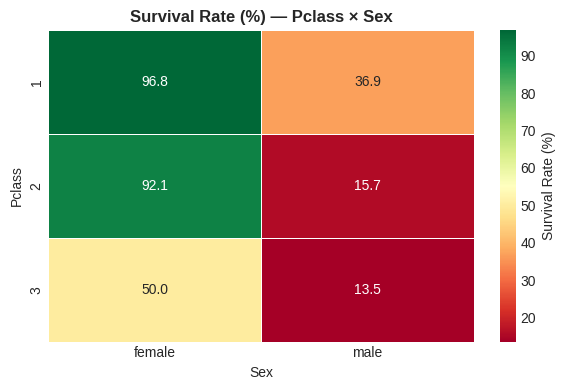

In [10]:
# --- Heatmap: Pclass × Sex survival rates ---
pivot = train.pivot_table(values='Survived', index='Pclass',
                          columns='Sex', aggfunc='mean') * 100
plt.figure(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=0.5, cbar_kws={'label': 'Survival Rate (%)'})
plt.title('Survival Rate (%) — Pclass × Sex', fontweight='bold')
plt.tight_layout()
plt.show()

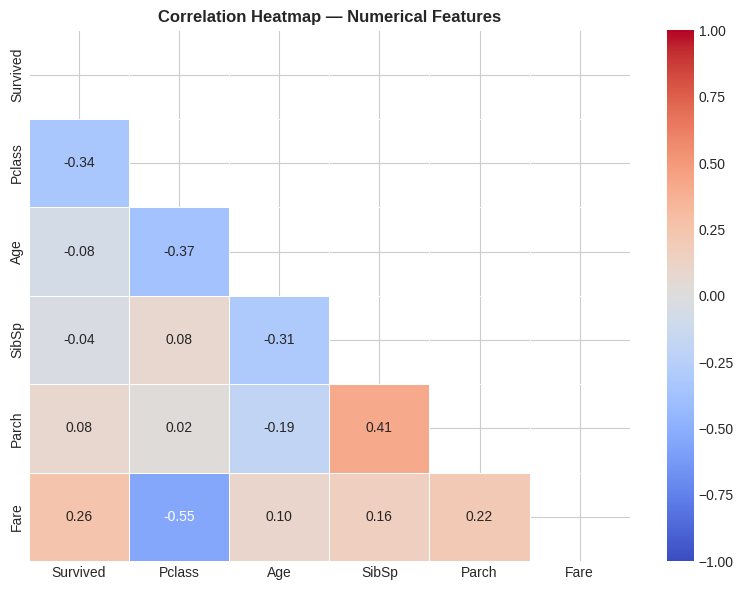

In [11]:
# --- Correlation heatmap ---
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train[num_cols].corr()

plt.figure(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features', fontweight='bold')
plt.tight_layout()
plt.show()

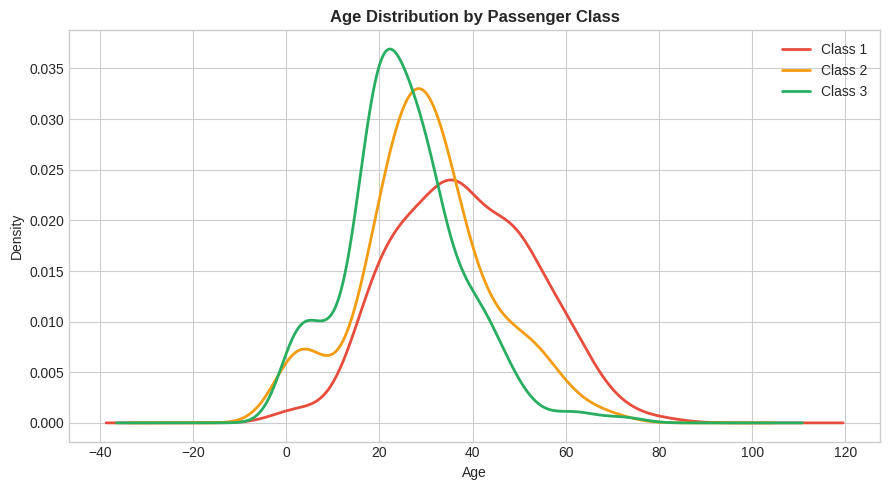

In [12]:
# --- Age distribution by Pclass ---
plt.figure(figsize=(9, 5))
for pclass, color in zip([1, 2, 3], ['#e74c3c', '#f39c12', '#27ae60']):
    train[train['Pclass'] == pclass]['Age'].dropna().plot(
        kind='kde', label=f'Class {pclass}', color=color, linewidth=2
    )
plt.title('Age Distribution by Passenger Class', fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

---
## Task 2 — Data Preprocessing

In [13]:
# Combine train + test for consistent preprocessing
test['Survived'] = np.nan  # placeholder
combined = pd.concat([train, test], ignore_index=True)
print('Combined shape:', combined.shape)

Combined shape: (1309, 12)


In [14]:
# --- Feature Engineering ---

# 1. Title extraction from Name
combined['Title'] = combined['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
title_map = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Countess': 'Rare', 'Ms': 'Miss', 'Lady': 'Rare',
    'Jonkheer': 'Rare', 'Don': 'Rare', 'Dona': 'Rare', 'Mme': 'Mrs',
    'Capt': 'Rare', 'Sir': 'Rare'
}
combined['Title'] = combined['Title'].map(title_map).fillna('Rare')
print('Title value counts:')
print(combined['Title'].value_counts().to_string())

Title value counts:
Title
Mr        757
Miss      264
Mrs       198
Master     61
Rare       29


In [15]:
# 2. FamilySize and IsAlone
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1
combined['IsAlone']    = (combined['FamilySize'] == 1).astype(int)

# 3. Cabin — derive HasCabin flag
combined['HasCabin'] = combined['Cabin'].notnull().astype(int)

print('FamilySize range:', combined['FamilySize'].min(), '-', combined['FamilySize'].max())
print('IsAlone distribution:', combined['IsAlone'].value_counts().to_dict())
print('HasCabin distribution:', combined['HasCabin'].value_counts().to_dict())

FamilySize range: 1 - 11
IsAlone distribution: {1: 790, 0: 519}
HasCabin distribution: {0: 1014, 1: 295}


In [16]:
# --- Handle Missing Values ---

# Age: fill by median within Pclass × Title groups
combined['Age'] = combined.groupby(['Pclass', 'Title'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
# Fallback for any still-null Age
combined['Age'].fillna(combined['Age'].median(), inplace=True)

# Fare: fill with median of same Pclass
combined['Fare'] = combined.groupby('Pclass')['Fare'].transform(
    lambda x: x.fillna(x.median())
)

# Embarked: fill with mode
combined['Embarked'].fillna(combined['Embarked'].mode()[0], inplace=True)

print('Remaining missing after imputation:')
remaining = combined[['Age', 'Fare', 'Embarked']].isnull().sum()
print(remaining)

Remaining missing after imputation:
Age         0
Fare        0
Embarked    2
dtype: int64


In [17]:
# --- Encode Categorical Variables ---

# Binary encode Sex
combined['Sex'] = combined['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encode Embarked
embarked_dummies = pd.get_dummies(combined['Embarked'], prefix='Emb', drop_first=False)
combined = pd.concat([combined, embarked_dummies], axis=1)

# Label Encode Title
le = LabelEncoder()
combined['Title_enc'] = le.fit_transform(combined['Title'])
print('Title encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# Age bins
combined['AgeBin'] = pd.cut(combined['Age'],
                             bins=[0, 12, 18, 35, 60, 100],
                             labels=[0, 1, 2, 3, 4]).astype(int)

# Fare bins (log transform to handle skew)
combined['LogFare'] = np.log1p(combined['Fare'])

print('\nEncoding complete.')

Title encoding: {'Master': np.int64(0), 'Miss': np.int64(1), 'Mr': np.int64(2), 'Mrs': np.int64(3), 'Rare': np.int64(4)}

Encoding complete.


In [18]:
# Select final features
features = ['Pclass', 'Sex', 'Age', 'LogFare', 'FamilySize', 'IsAlone',
            'HasCabin', 'Title_enc', 'AgeBin', 'SibSp', 'Parch',
            'Emb_C', 'Emb_Q', 'Emb_S']

# Split back to train / test
train_proc = combined[combined['Survived'].notna()].copy()
test_proc  = combined[combined['Survived'].isna()].copy()

X_all  = train_proc[features]
y_all  = train_proc['Survived'].astype(int)
X_kaggle = test_proc[features]

print('X_all shape:', X_all.shape)
print('y_all shape:', y_all.shape)
print('X_kaggle shape:', X_kaggle.shape)
print('Features used:', features)

X_all shape: (891, 14)
y_all shape: (891,)
X_kaggle shape: (418, 14)
Features used: ['Pclass', 'Sex', 'Age', 'LogFare', 'FamilySize', 'IsAlone', 'HasCabin', 'Title_enc', 'AgeBin', 'SibSp', 'Parch', 'Emb_C', 'Emb_Q', 'Emb_S']


---
## Task 3 — Model Building

In [19]:
# Train-validation split (80/20) from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'Train size : {len(X_train)} | Validation size: {len(X_val)}')

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_all_sc   = scaler.transform(X_all)
X_kaggle_sc = scaler.transform(X_kaggle)
print('Scaling complete.')

Train size : 712 | Validation size: 179
Scaling complete.


In [20]:
# Build Logistic Regression model
lr_model = LogisticRegression(
    C=1.0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train_sc, y_train)
print('Logistic Regression model trained.')
print(f'  Solver      : lbfgs')
print(f'  Regularisation C : 1.0')
print(f'  Max Iterations   : 1000')

Logistic Regression model trained.
  Solver      : lbfgs
  Regularisation C : 1.0
  Max Iterations   : 1000


In [21]:
# Cross-validation on full training data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr_model, X_all_sc, y_all, cv=skf, scoring='accuracy')
print('5-Fold Stratified CV Accuracy:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'  Mean  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold Stratified CV Accuracy:
  Fold 1: 0.7877
  Fold 2: 0.8315
  Fold 3: 0.7809
  Fold 4: 0.8090
  Fold 5: 0.8427
  Mean  : 0.8104 ± 0.0240


---
## Task 4 — Model Evaluation

In [22]:
# Predictions on validation set
y_pred      = lr_model.predict(X_val_sc)
y_prob      = lr_model.predict_proba(X_val_sc)[:, 1]

acc  = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred, zero_division=0)
rec  = recall_score(y_val, y_pred, zero_division=0)
f1   = f1_score(y_val, y_pred, zero_division=0)
auc  = roc_auc_score(y_val, y_prob)

print('=' * 55)
print('LOGISTIC REGRESSION — VALIDATION PERFORMANCE')
print('=' * 55)
print(f'  Accuracy   : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision  : {prec:.4f}')
print(f'  Recall     : {rec:.4f}')
print(f'  F1-Score   : {f1:.4f}')
print(f'  ROC-AUC    : {auc:.4f}')
print('=' * 55)

LOGISTIC REGRESSION — VALIDATION PERFORMANCE
  Accuracy   : 0.8156  (81.56%)
  Precision  : 0.7812
  Recall     : 0.7246
  F1-Score   : 0.7519
  ROC-AUC    : 0.8477


In [23]:
# Classification report
print('Classification Report:')
print(classification_report(y_val, y_pred,
                             target_names=['Not Survived', 'Survived']))

Classification Report:


              precision    recall  f1-score   support

Not Survived       0.83      0.87      0.85       110
    Survived       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



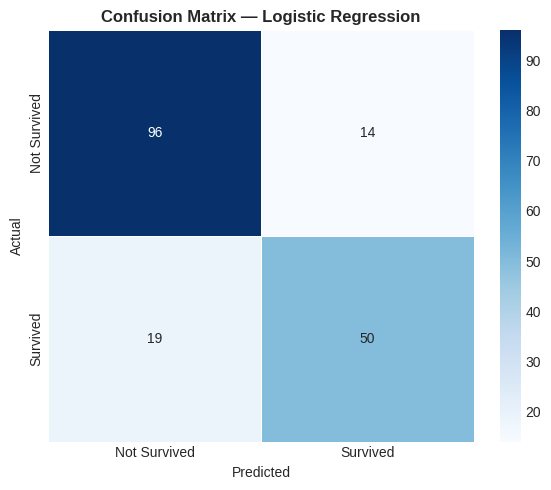

TN=96  FP=14  FN=19  TP=50


In [24]:
# Confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'],
            linewidths=0.5)
plt.title('Confusion Matrix — Logistic Regression', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')

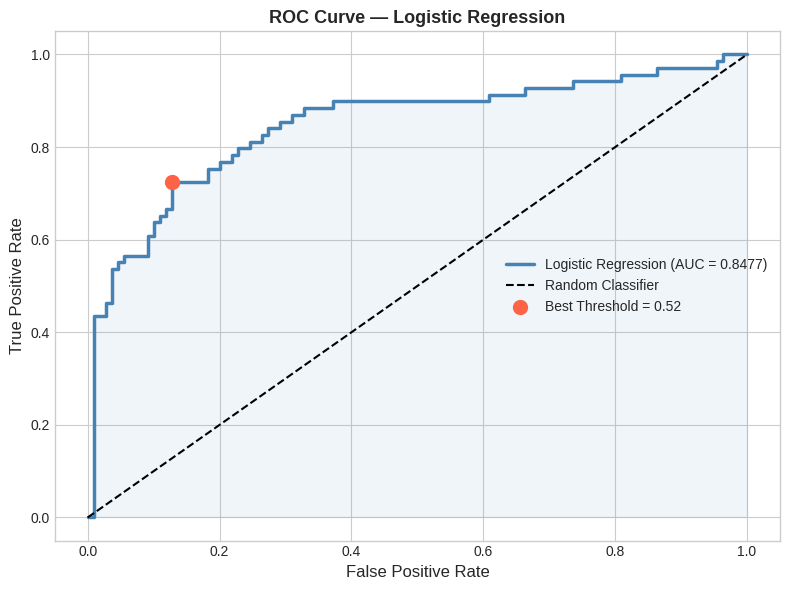

In [25]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', linewidth=2.5,
         label=f'Logistic Regression (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark optimal threshold (Youden's J)
j_scores = tpr - fpr
best_idx = np.argmax(j_scores)
plt.scatter(fpr[best_idx], tpr[best_idx], s=100, color='tomato', zorder=5,
            label=f'Best Threshold = {thresholds[best_idx]:.2f}')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Logistic Regression', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

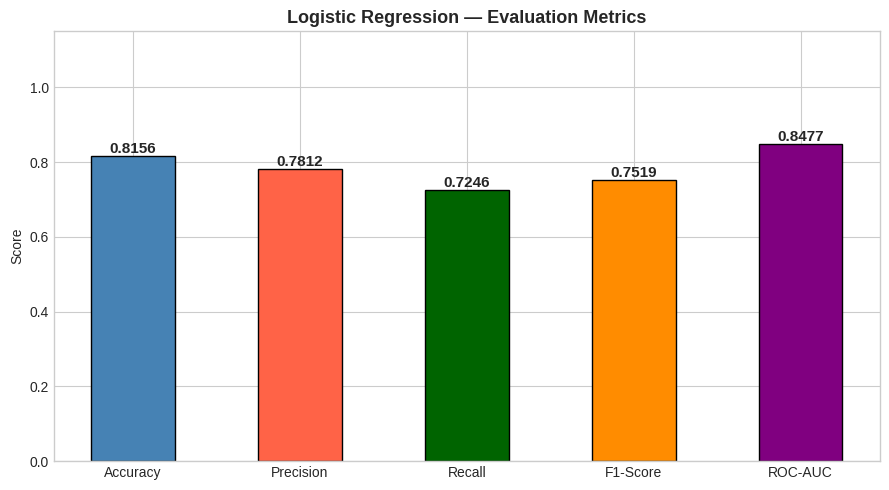

In [26]:
# Metrics summary bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
metric_vals   = [acc, prec, rec, f1, auc]
metric_colors = ['steelblue','tomato','darkgreen','darkorange','purple']

plt.figure(figsize=(9, 5))
bars = plt.bar(metric_names, metric_vals, color=metric_colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, metric_vals):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
             f'{v:.4f}', ha='center', fontweight='bold', fontsize=11)
plt.ylim(0, 1.15)
plt.title('Logistic Regression — Evaluation Metrics', fontweight='bold', fontsize=13)
plt.ylabel('Score')
plt.tight_layout()
plt.show()

---
## Task 5 — Model Interpretation

In [27]:
# Coefficients
coef_df = pd.DataFrame({
    'Feature'    : features,
    'Coefficient': lr_model.coef_[0],
    'Odds Ratio' : np.exp(lr_model.coef_[0])
}).sort_values('Coefficient', ascending=False)

print('Logistic Regression Coefficients:')
print(coef_df.to_string(index=False))

Logistic Regression Coefficients:
   Feature  Coefficient  Odds Ratio
       Sex     1.205661    3.338964
  HasCabin     0.336177    1.399587
   LogFare     0.329731    1.390594
 Title_enc     0.043366    1.044320
     Emb_Q    -0.008217    0.991817
     Parch    -0.077137    0.925763
     Emb_C    -0.125181    0.882337
       Age    -0.186447    0.829903
   IsAlone    -0.207576    0.812552
     Emb_S    -0.217031    0.804905
FamilySize    -0.283023    0.753502
     SibSp    -0.363043    0.695557
    AgeBin    -0.475190    0.621767
    Pclass    -0.600907    0.548314


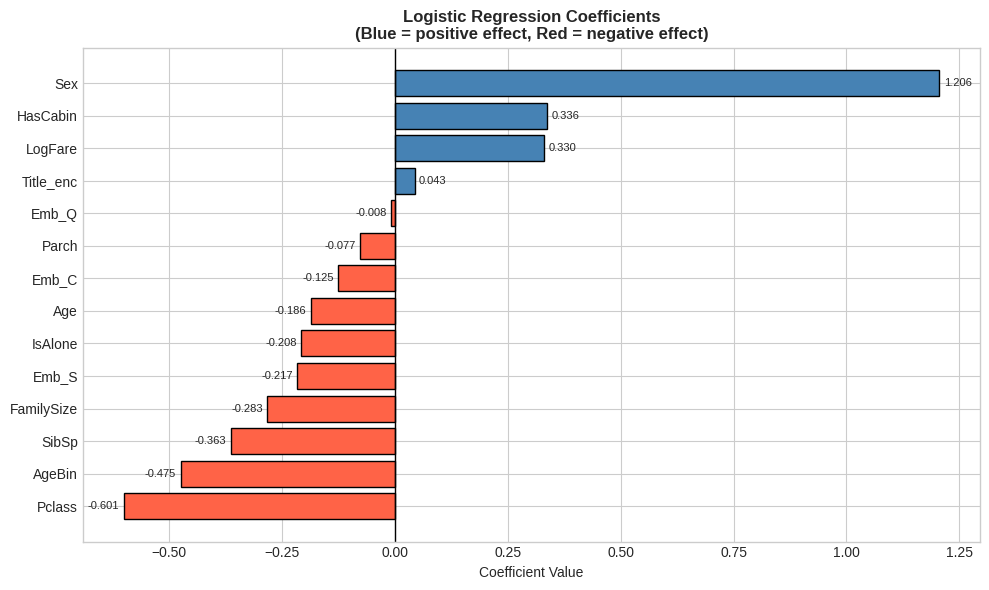

In [28]:
# Coefficient bar chart
coef_sorted = coef_df.sort_values('Coefficient')
colors_coef = ['tomato' if v < 0 else 'steelblue' for v in coef_sorted['Coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_sorted['Feature'], coef_sorted['Coefficient'],
                color=colors_coef, edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.title('Logistic Regression Coefficients\n(Blue = positive effect, Red = negative effect)',
          fontweight='bold', fontsize=12)
plt.xlabel('Coefficient Value')
for bar, v in zip(bars, coef_sorted['Coefficient']):
    x_pos = v + 0.01 if v >= 0 else v - 0.01
    ha = 'left' if v >= 0 else 'right'
    plt.text(x_pos, bar.get_y()+bar.get_height()/2,
             f'{v:.3f}', va='center', ha=ha, fontsize=8)
plt.tight_layout()
plt.show()

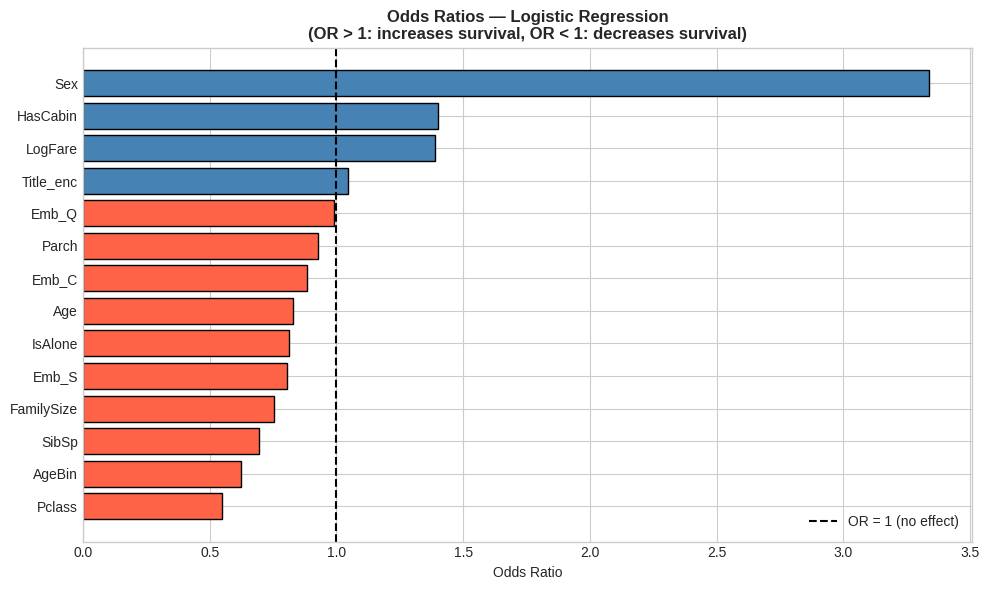

In [29]:
# Odds Ratio chart
odds_sorted = coef_df.sort_values('Odds Ratio')
colors_odds = ['tomato' if v < 1 else 'steelblue' for v in odds_sorted['Odds Ratio']]

plt.figure(figsize=(10, 6))
bars = plt.barh(odds_sorted['Feature'], odds_sorted['Odds Ratio'],
                color=colors_odds, edgecolor='black')
plt.axvline(1, color='black', linewidth=1.5, linestyle='--', label='OR = 1 (no effect)')
plt.title('Odds Ratios — Logistic Regression\n(OR > 1: increases survival, OR < 1: decreases survival)',
          fontweight='bold', fontsize=12)
plt.xlabel('Odds Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
# Interpretation summary
print('=' * 65)
print('COEFFICIENT INTERPRETATION')
print('=' * 65)
for _, row in coef_df.iterrows():
    direction = 'INCREASES' if row['Coefficient'] > 0 else 'DECREASES'
    print(f'  {row["Feature"]:<15}: coef={row["Coefficient"]:+.3f}  '
          f'OR={row["Odds Ratio"]:.3f}  → {direction} survival probability')
print('=' * 65)
print()
print('Top 3 features INCREASING survival:')
top3_pos = coef_df[coef_df['Coefficient'] > 0].head(3)
for _, row in top3_pos.iterrows():
    print(f'  {row["Feature"]:15} (coef={row["Coefficient"]:+.3f}, OR={row["Odds Ratio"]:.3f})')
print()
print('Top 3 features DECREASING survival:')
top3_neg = coef_df[coef_df['Coefficient'] < 0].tail(3)
for _, row in top3_neg.iterrows():
    print(f'  {row["Feature"]:15} (coef={row["Coefficient"]:+.3f}, OR={row["Odds Ratio"]:.3f})')

COEFFICIENT INTERPRETATION
  Sex            : coef=+1.206  OR=3.339  → INCREASES survival probability
  HasCabin       : coef=+0.336  OR=1.400  → INCREASES survival probability
  LogFare        : coef=+0.330  OR=1.391  → INCREASES survival probability
  Title_enc      : coef=+0.043  OR=1.044  → INCREASES survival probability
  Emb_Q          : coef=-0.008  OR=0.992  → DECREASES survival probability
  Parch          : coef=-0.077  OR=0.926  → DECREASES survival probability
  Emb_C          : coef=-0.125  OR=0.882  → DECREASES survival probability
  Age            : coef=-0.186  OR=0.830  → DECREASES survival probability
  IsAlone        : coef=-0.208  OR=0.813  → DECREASES survival probability
  Emb_S          : coef=-0.217  OR=0.805  → DECREASES survival probability
  FamilySize     : coef=-0.283  OR=0.754  → DECREASES survival probability
  SibSp          : coef=-0.363  OR=0.696  → DECREASES survival probability
  AgeBin         : coef=-0.475  OR=0.622  → DECREASES survival probabilit

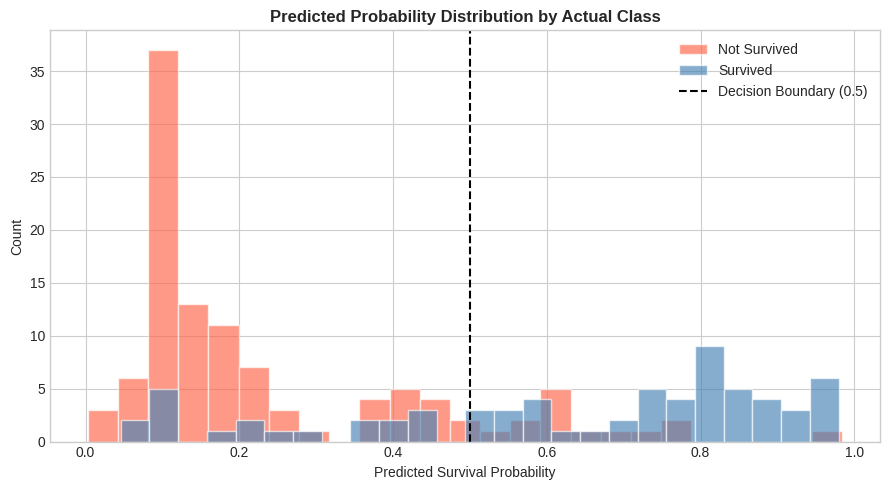

In [31]:
# Predicted survival probability distribution
plt.figure(figsize=(9, 5))
for label, color, name in zip([0,1], ['tomato','steelblue'],
                                ['Not Survived','Survived']):
    mask = y_val.values == label
    plt.hist(y_prob[mask], bins=25, alpha=0.65, color=color,
             edgecolor='white', label=name)
plt.axvline(0.5, color='black', linestyle='--', linewidth=1.5,
            label='Decision Boundary (0.5)')
plt.xlabel('Predicted Survival Probability')
plt.ylabel('Count')
plt.title('Predicted Probability Distribution by Actual Class',
          fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## Task 6 — Kaggle Test Predictions + Streamlit App

In [32]:
# Retrain on full training data before predicting on Kaggle test
lr_full = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_full.fit(X_all_sc, y_all)

# Predictions on Titanic_test.csv
test_preds = lr_full.predict(X_kaggle_sc)

submission = pd.DataFrame({
    'PassengerId': test_proc['PassengerId'].values,
    'Survived'   : test_preds
})
submission.to_csv('titanic_submission.csv', index=False)
print('Predictions saved to titanic_submission.csv')
print(f'Predicted survivors : {test_preds.sum()} / {len(test_preds)}')
submission.head(10)

Predictions saved to titanic_submission.csv
Predicted survivors : 152 / 418


,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [33]:
# Save model and scaler for Streamlit deployment
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr_full, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Model and scaler saved as lr_model.pkl and scaler.pkl')

Model and scaler saved as lr_model.pkl and scaler.pkl


In [34]:
# Streamlit app code (save as app.py to run locally)
streamlit_code = '''
import streamlit as st
import numpy as np
import pickle

# Load model and scaler
with open('lr_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

st.set_page_config(page_title='Titanic Survival Predictor', page_icon='🚢')
st.title('🚢 Titanic Survival Predictor')
st.markdown('### Enter passenger details to predict survival probability')
st.markdown('---')

col1, col2 = st.columns(2)

with col1:
    pclass     = st.selectbox('Passenger Class', [1, 2, 3],
                              help='1=First, 2=Second, 3=Third')
    sex        = st.selectbox('Sex', ['male', 'female'])
    age        = st.slider('Age', 1, 80, 30)
    fare       = st.slider('Fare (£)', 0.0, 512.0, 32.0)
    embarked   = st.selectbox('Port of Embarkation',
                              ['S', 'C', 'Q'],
                              help='S=Southampton, C=Cherbourg, Q=Queenstown')

with col2:
    sibsp      = st.number_input('Siblings / Spouses aboard', 0, 8, 0)
    parch      = st.number_input('Parents / Children aboard', 0, 6, 0)
    has_cabin  = st.selectbox('Has Cabin Info?', [0, 1])
    title_map_ui = {'Mr': 0, 'Miss': 1, 'Mrs': 2, 'Master': 3, 'Rare': 4}
    title_sel  = st.selectbox('Title', list(title_map_ui.keys()))

# Derived features
sex_enc      = 0 if sex == 'male' else 1
family_size  = sibsp + parch + 1
is_alone     = 1 if family_size == 1 else 0
log_fare     = np.log1p(fare)
title_enc    = title_map_ui[title_sel]
age_bin      = 0 if age <= 12 else (1 if age <= 18 else (2 if age <= 35 else (3 if age <= 60 else 4)))
emb_c        = 1 if embarked == 'C' else 0
emb_q        = 1 if embarked == 'Q' else 0
emb_s        = 1 if embarked == 'S' else 0

input_data = np.array([[pclass, sex_enc, age, log_fare, family_size, is_alone,
                         has_cabin, title_enc, age_bin, sibsp, parch,
                         emb_c, emb_q, emb_s]])

input_scaled = scaler.transform(input_data)

st.markdown('---')
if st.button('🔍 Predict Survival', use_container_width=True):
    prob    = model.predict_proba(input_scaled)[0][1]
    outcome = 'SURVIVED 🟢' if prob >= 0.5 else 'DID NOT SURVIVE 🔴'

    st.markdown(f'### Prediction: **{outcome}**')
    st.progress(float(prob))
    st.metric(label='Survival Probability', value=f'{prob*100:.1f}%')

    st.markdown('#### Input Summary')
    st.table({
        'Feature': ['Class', 'Sex', 'Age', 'Fare', 'Family Size', 'Alone', 'Embarked'],
        'Value'  : [pclass, sex, age, f'£{fare:.2f}', family_size,
                    'Yes' if is_alone else 'No', embarked]
    })

st.markdown('---')
st.caption('Model: Logistic Regression trained on Titanic train dataset')
'''

with open('app.py', 'w') as f:
    f.write(streamlit_code)

print('Streamlit app saved as app.py')
print('To run locally: streamlit run app.py')

Streamlit app saved as app.py
To run locally: streamlit run app.py


In [35]:
# Print the Streamlit app code for review
print(streamlit_code)


import streamlit as st
import numpy as np
import pickle

# Load model and scaler
with open('lr_model.pkl', 'rb') as f:
    model = pickle.load(f)
with open('scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

st.set_page_config(page_title='Titanic Survival Predictor', page_icon='🚢')
st.title('🚢 Titanic Survival Predictor')
st.markdown('### Enter passenger details to predict survival probability')
st.markdown('---')

col1, col2 = st.columns(2)

with col1:
    pclass     = st.selectbox('Passenger Class', [1, 2, 3],
                              help='1=First, 2=Second, 3=Third')
    sex        = st.selectbox('Sex', ['male', 'female'])
    age        = st.slider('Age', 1, 80, 30)
    fare       = st.slider('Fare (£)', 0.0, 512.0, 32.0)
    embarked   = st.selectbox('Port of Embarkation',
                              ['S', 'C', 'Q'],
                              help='S=Southampton, C=Cherbourg, Q=Queenstown')

with col2:
    sibsp      = st.number_input('Siblings / Spouses aboard', 0

---
## Interview Questions

### Q1. What is the difference between Precision and Recall?

| Metric | Formula | Focus | Use When |
|---|---|---|---|
| **Precision** | TP / (TP + FP) | Of all predicted positives, how many are actually positive? | Costly false positives (e.g., spam filter — don't mark real emails as spam) |
| **Recall** | TP / (TP + FN) | Of all actual positives, how many did the model catch? | Costly false negatives (e.g., cancer screening — don't miss sick patients) |

**Trade-off:** Increasing the decision threshold raises Precision but lowers Recall, and vice versa.  
**F1-Score** is the harmonic mean of both: `2 × (P × R) / (P + R)` — useful when you need a single balanced metric.

**In this Titanic problem:**  
- High **Recall** matters if we prioritise detecting survivors (minimise missed rescues).  
- High **Precision** matters if we care about not falsely predicting survival for non-survivors.

---

### Q2. What is Cross-Validation and why is it important in Binary Classification?

**Cross-validation (CV)** is a model evaluation technique that partitions the training data into K equal folds and trains/evaluates the model K times, each time using a different fold as the validation set and the remaining K-1 folds as training data. The final score is the average across all K folds.

| Aspect | Details |
|---|---|
| **Types** | K-Fold, Stratified K-Fold, Leave-One-Out (LOO), Repeated K-Fold |
| **Purpose** | Reduces variance of evaluation, detects overfitting |
| **Why Stratified CV for binary** | Ensures each fold preserves the same class ratio as the full set — critical when classes are imbalanced (like Titanic: 62% died, 38% survived) |
| **Benefit over single split** | More reliable performance estimate — uses all data for both training and evaluation across folds |
| **Limitation** | Computationally expensive for large datasets (K× training cost) |

**In this model:** 5-fold Stratified CV was used to get a reliable accuracy estimate without touching the test set, preventing data leakage and overfitting to a specific validation split.

In [36]:
# Final summary
print('=' * 55)
print('FINAL MODEL SUMMARY')
print('=' * 55)
print(f'  Model          : Logistic Regression')
print(f'  Train samples  : {len(X_train)}')
print(f'  Val samples    : {len(X_val)}')
print(f'  Features used  : {len(features)}')
print()
print(f'  CV Accuracy    : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'  Val Accuracy   : {acc:.4f}')
print(f'  Val Precision  : {prec:.4f}')
print(f'  Val Recall     : {rec:.4f}')
print(f'  Val F1-Score   : {f1:.4f}')
print(f'  Val ROC-AUC    : {auc:.4f}')
print()
print(f'  Test preds     : titanic_submission.csv')
print(f'  Streamlit app  : app.py')
print('=' * 55)

FINAL MODEL SUMMARY
  Model          : Logistic Regression
  Train samples  : 712
  Val samples    : 179
  Features used  : 14

  CV Accuracy    : 0.8104 ± 0.0240
  Val Accuracy   : 0.8156
  Val Precision  : 0.7812
  Val Recall     : 0.7246
  Val F1-Score   : 0.7519
  Val ROC-AUC    : 0.8477

  Test preds     : titanic_submission.csv
  Streamlit app  : app.py
